<a href="https://colab.research.google.com/github/anderson-perez/DEC7562/Extras/blob/main/Simulador_Escalonamento_Tarefas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistemas Operacionais Embarcados

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/DEC7562.git)

# Sobre

Este notebook apresenta uma simulação didática de três algoritmos clássicos de escalonamento:

- **Round-Robin (RR)**
- **Escalonamento por Prioridade**
- **Earliest Deadline First (EDF)**

O objetivo é visualizar como cada algoritmo escolhe a próxima tarefa a executar e comparar métricas como:

- tempo de espera;
- tempo de retorno (*turnaround time*);
- tempo de resposta;
- número de trocas de contexto;
- atendimento ou perda de *deadlines*.

> **Observação 1:** a simulação usa tempo discreto e tarefas executadas em uma única CPU.

> **Observação 1:** o notebook foi elaborado pelo chatgpt.

# Implementação

## Modelo das tarefas

Cada tarefa será representada por:

| Campo | Significado |
|---|---|
| `nome` | Identificador da tarefa |
| `chegada` | Instante em que a tarefa fica pronta |
| `execucao` | Tempo total de CPU necessário |
| `prioridade` | Valor numérico de prioridade |
| `deadline` | Prazo absoluto para conclusão |

Neste notebook, **menor valor de prioridade significa maior prioridade**.

In [ ]:
from dataclasses import dataclass, field
from collections import deque
import copy
import pandas as pd
import matplotlib.pyplot as plt

@dataclass
class Tarefa:
    nome: str
    chegada: int
    execucao: int
    prioridade: int = 0
    deadline: int = 999
    restante: int = field(init=False)
    inicio: int = field(default=None, init=False)
    fim: int = field(default=None, init=False)

    def __post_init__(self):
        self.restante = self.execucao

def copiar_tarefas(tarefas):
    return copy.deepcopy(tarefas)

## Funções auxiliares

As funções abaixo calculam métricas e desenham um gráfico de Gantt simplificado.

In [ ]:
def calcular_metricas(tarefas, timeline):
    resultados = []

    for t in tarefas:
        turnaround = t.fim - t.chegada
        espera = turnaround - t.execucao
        resposta = t.inicio - t.chegada
        deadline_ok = t.fim <= t.deadline

        resultados.append({
            "Tarefa": t.nome,
            "Chegada": t.chegada,
            "Execução": t.execucao,
            "Início": t.inicio,
            "Fim": t.fim,
            "Espera": espera,
            "Retorno": turnaround,
            "Resposta": resposta,
            "Deadline": t.deadline,
            "Deadline atendido": deadline_ok
        })

    trocas = 0
    anterior = None

    for _, nome in timeline:
        if nome != "IDLE":
            if anterior is not None and nome != anterior:
                trocas += 1
            anterior = nome

    return pd.DataFrame(resultados), trocas


def plotar_gantt(timeline, titulo):
    if not timeline:
        return

    nomes = []
    for _, nome in timeline:
        if nome not in nomes:
            nomes.append(nome)

    ymap = {nome: i for i, nome in enumerate(nomes)}

    fig, ax = plt.subplots(figsize=(12, 3))

    inicio_bloco = timeline[0][0]
    tarefa_atual = timeline[0][1]

    for i in range(1, len(timeline) + 1):
        mudou = (
            i == len(timeline)
            or timeline[i][1] != tarefa_atual
        )

        if mudou:
            fim_bloco = timeline[i-1][0] + 1
            ax.barh(
                ymap[tarefa_atual],
                fim_bloco - inicio_bloco,
                left=inicio_bloco,
                edgecolor="black"
            )

            ax.text(
                (inicio_bloco + fim_bloco) / 2,
                ymap[tarefa_atual],
                tarefa_atual,
                ha="center",
                va="center"
            )

            if i < len(timeline):
                inicio_bloco = timeline[i][0]
                tarefa_atual = timeline[i][1]

    ax.set_yticks(list(ymap.values()))
    ax.set_yticklabels(list(ymap.keys()))
    ax.set_xlabel("Tempo")
    ax.set_title(titulo)
    ax.grid(axis="x", linestyle="--", alpha=0.4)
    plt.show()

## Algoritmos de Escalonamento

#### Round-Robin

O **Round-Robin** utiliza uma fila circular de tarefas prontas.

Cada tarefa recebe a CPU durante no máximo um intervalo chamado **quantum**.

Quando o quantum termina:

- se a tarefa concluiu, ela sai da fila;
- caso contrário, retorna para o final da fila.

É um algoritmo preemptivo e bastante utilizado em sistemas de tempo compartilhado.

In [ ]:
def round_robin(tarefas, quantum=2):
    tarefas = copiar_tarefas(tarefas)
    fila = deque()
    timeline = []

    tempo = 0
    concluidas = 0
    total = len(tarefas)
    nomes_na_fila = set()

    while concluidas < total:

        for t in tarefas:
            if t.chegada <= tempo and t.restante > 0 and t.nome not in nomes_na_fila:
                if t.inicio is None or t.restante == t.execucao:
                    fila.append(t)
                    nomes_na_fila.add(t.nome)

        if not fila:
            timeline.append((tempo, "IDLE"))
            tempo += 1
            continue

        atual = fila.popleft()
        nomes_na_fila.remove(atual.nome)

        if atual.inicio is None:
            atual.inicio = tempo

        usado = 0

        while usado < quantum and atual.restante > 0:
            timeline.append((tempo, atual.nome))
            atual.restante -= 1
            tempo += 1
            usado += 1

            # adiciona novas tarefas que chegaram durante a execução
            for t in tarefas:
                if (
                    t.chegada <= tempo
                    and t.restante > 0
                    and t.nome not in nomes_na_fila
                    and t.nome != atual.nome
                ):
                    fila.append(t)
                    nomes_na_fila.add(t.nome)

        if atual.restante == 0:
            atual.fim = tempo
            concluidas += 1
        else:
            fila.append(atual)
            nomes_na_fila.add(atual.nome)

    metricas, trocas = calcular_metricas(tarefas, timeline)
    return tarefas, timeline, metricas, trocas

#### Escalonamento por Prioridade

No escalonamento por prioridade, a CPU é entregue à tarefa pronta com **maior prioridade**.

Neste exemplo:

> menor número = maior prioridade

Por exemplo:

- prioridade 1 → alta;
- prioridade 2 → média;
- prioridade 3 → baixa.

A implementação abaixo é **preemptiva**. Portanto, uma tarefa de maior prioridade pode interromper uma tarefa que está executando.

In [ ]:
def escalonamento_prioridade(tarefas):
    tarefas = copiar_tarefas(tarefas)
    timeline = []

    tempo = 0
    concluidas = 0

    while concluidas < len(tarefas):

        prontas = [
            t for t in tarefas
            if t.chegada <= tempo and t.restante > 0
        ]

        if not prontas:
            timeline.append((tempo, "IDLE"))
            tempo += 1
            continue

        atual = min(
            prontas,
            key=lambda t: (t.prioridade, t.chegada, t.nome)
        )

        if atual.inicio is None:
            atual.inicio = tempo

        timeline.append((tempo, atual.nome))
        atual.restante -= 1
        tempo += 1

        if atual.restante == 0:
            atual.fim = tempo
            concluidas += 1

    metricas, trocas = calcular_metricas(tarefas, timeline)
    return tarefas, timeline, metricas, trocas

#### Earliest Deadline First — EDF

O **EDF (Earliest Deadline First)** seleciona a tarefa pronta que possui o **deadline absoluto mais próximo**.

Assim, entre duas tarefas prontas:

- deadline = 8
- deadline = 12

a tarefa com deadline 8 será executada primeiro.

O EDF é um algoritmo dinâmico e preemptivo amplamente estudado em sistemas de tempo real.

In [ ]:
def edf(tarefas):
    tarefas = copiar_tarefas(tarefas)
    timeline = []

    tempo = 0
    concluidas = 0

    while concluidas < len(tarefas):

        prontas = [
            t for t in tarefas
            if t.chegada <= tempo and t.restante > 0
        ]

        if not prontas:
            timeline.append((tempo, "IDLE"))
            tempo += 1
            continue

        atual = min(
            prontas,
            key=lambda t: (t.deadline, t.chegada, t.nome)
        )

        if atual.inicio is None:
            atual.inicio = tempo

        timeline.append((tempo, atual.nome))
        atual.restante -= 1
        tempo += 1

        if atual.restante == 0:
            atual.fim = tempo
            concluidas += 1

    metricas, trocas = calcular_metricas(tarefas, timeline)
    return tarefas, timeline, metricas, trocas

# Exemplo

Você pode alterar os valores abaixo e executar novamente as células para observar o comportamento dos algoritmos.

In [ ]:
tarefas = [
    Tarefa("T1", chegada=0, execucao=5, prioridade=2, deadline=10),
    Tarefa("T2", chegada=1, execucao=3, prioridade=1, deadline=7),
    Tarefa("T3", chegada=2, execucao=4, prioridade=3, deadline=14),
    Tarefa("T4", chegada=4, execucao=2, prioridade=1, deadline=9),
]

df = pd.DataFrame([
    {
        "Tarefa": t.nome,
        "Chegada": t.chegada,
        "Execução": t.execucao,
        "Prioridade": t.prioridade,
        "Deadline": t.deadline
    }
    for t in tarefas
])

df

,Tarefa,Chegada,Execução,Prioridade,Deadline
0,T1,0,5,2,10
1,T2,1,3,1,7
2,T3,2,4,3,14
3,T4,4,2,1,9


## Simulação com Round-Robin

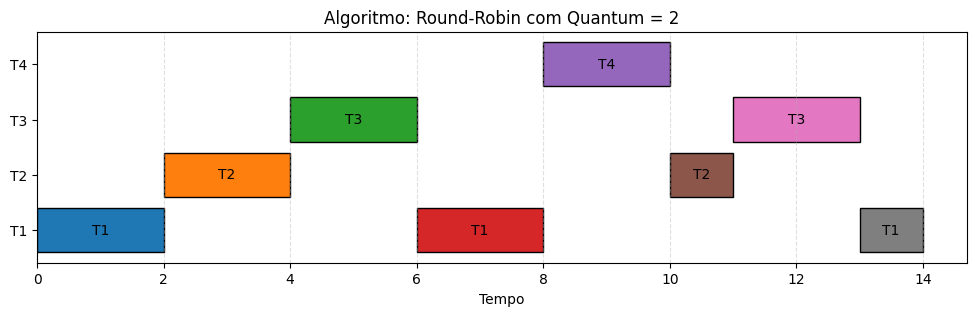

Trocas de contexto: 7


,Tarefa,Chegada,Execução,Início,Fim,Espera,Retorno,Resposta,Deadline,Deadline atendido
0,T1,0,5,0,14,9,14,0,10,False
1,T2,1,3,2,11,7,10,1,7,False
2,T3,2,4,4,13,7,11,2,14,True
3,T4,4,2,8,10,4,6,4,9,False


In [ ]:
tarefas_rr, timeline_rr, metricas_rr, trocas_rr = round_robin(tarefas, quantum=2)

plotar_gantt(timeline_rr, "Algoritmo: Round-Robin com Quantum = 2")

print("Trocas de contexto:", trocas_rr)
metricas_rr

## Simulação com Algoritmo Baseado em Prioridades

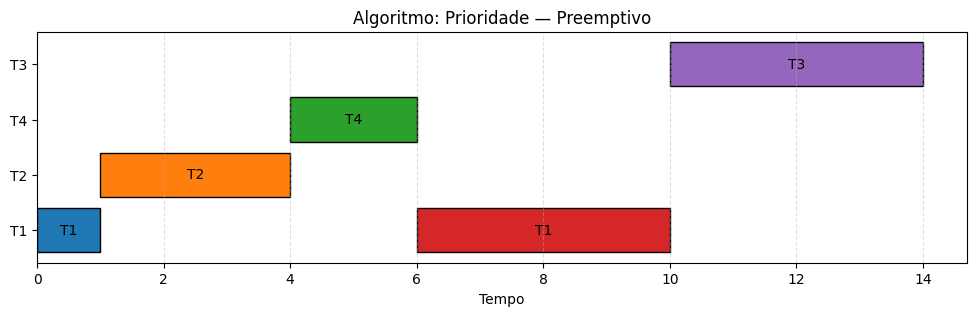

Trocas de contexto: 4


,Tarefa,Chegada,Execução,Início,Fim,Espera,Retorno,Resposta,Deadline,Deadline atendido
0,T1,0,5,0,10,5,10,0,10,True
1,T2,1,3,1,4,0,3,0,7,True
2,T3,2,4,10,14,8,12,8,14,True
3,T4,4,2,4,6,0,2,0,9,True


In [ ]:
tarefas_prio, timeline_prio, metricas_prio, trocas_prio = escalonamento_prioridade(tarefas)

plotar_gantt(timeline_prio, "Algoritmo: Prioridade — Preemptivo")

print("Trocas de contexto:", trocas_prio)
metricas_prio

### Observação: starvation

Um problema clássico do escalonamento por prioridade é o **starvation**.

Uma tarefa de baixa prioridade pode esperar indefinidamente caso tarefas de prioridade mais alta continuem chegando.

Uma solução comum é o **aging**, que aumenta gradualmente a prioridade das tarefas que permanecem muito tempo esperando.

## Simulação com o EDF

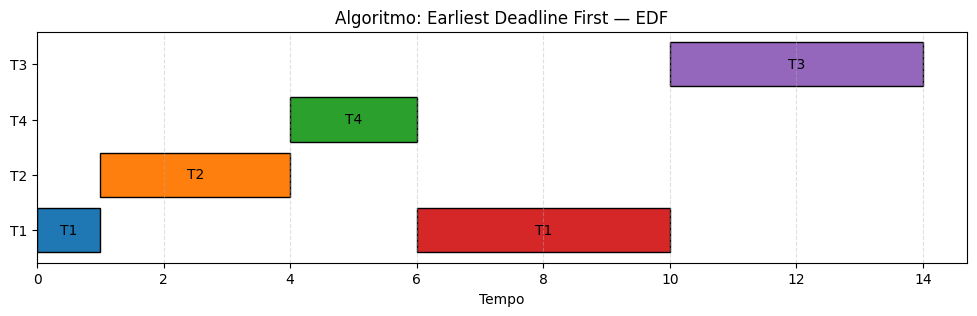

Trocas de contexto: 4


,Tarefa,Chegada,Execução,Início,Fim,Espera,Retorno,Resposta,Deadline,Deadline atendido
0,T1,0,5,0,10,5,10,0,10,True
1,T2,1,3,1,4,0,3,0,7,True
2,T3,2,4,10,14,8,12,8,14,True
3,T4,4,2,4,6,0,2,0,9,True


In [ ]:
tarefas_edf, timeline_edf, metricas_edf, trocas_edf = edf(tarefas)

plotar_gantt(timeline_edf, "Algoritmo: Earliest Deadline First — EDF")

print("Trocas de contexto:", trocas_edf)
metricas_edf

## Comparação dos algoritmos

In [ ]:
def resumo_algoritmo(nome, metricas, trocas):
    return {
        "Algoritmo": nome,
        "Espera média": metricas["Espera"].mean(),
        "Retorno médio": metricas["Retorno"].mean(),
        "Resposta média": metricas["Resposta"].mean(),
        "Trocas de contexto": trocas,
        "Deadlines perdidos": (~metricas["Deadline atendido"]).sum()
    }

comparacao = pd.DataFrame([
    resumo_algoritmo("Round-Robin", metricas_rr, trocas_rr),
    resumo_algoritmo("Prioridade", metricas_prio, trocas_prio),
    resumo_algoritmo("EDF", metricas_edf, trocas_edf)
])

comparacao

,Algoritmo,Espera média,Retorno médio,Resposta média,Trocas de contexto,Deadlines perdidos
0,Round-Robin,6.75,10.25,1.75,7,3
1,Prioridade,3.25,6.75,2.00,4,0
2,EDF,3.25,6.75,2.00,4,0


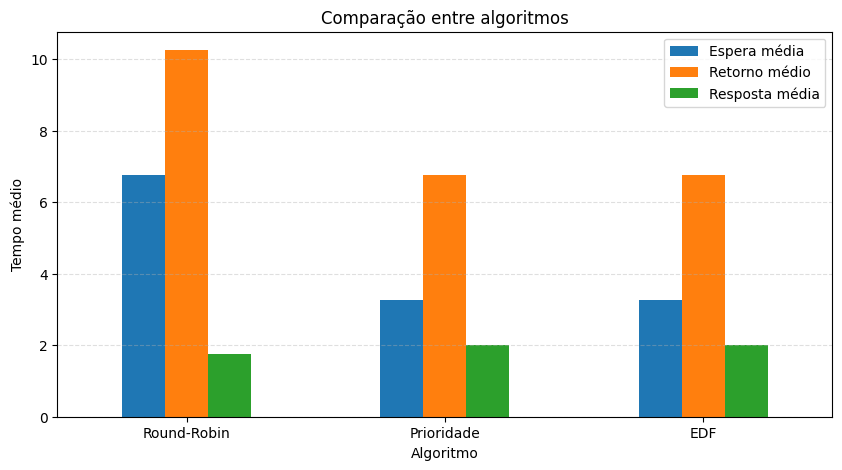

In [ ]:
comparacao.set_index("Algoritmo")[
    ["Espera média", "Retorno médio", "Resposta média"]
].plot(kind="bar", figsize=(10, 5))

plt.ylabel("Tempo médio")
plt.title("Comparação entre algoritmos")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

## Visualização lado a lado das linhas do tempo

A célula abaixo imprime a sequência de execução a cada unidade de tempo.

In [ ]:
def imprimir_timeline(nome, timeline):
    print(nome)
    print("Tempo :", " ".join(f"{t:>3}" for t, _ in timeline))
    print("CPU   :", " ".join(f"{n:>3}" for _, n in timeline))
    print()

imprimir_timeline("ROUND-ROBIN", timeline_rr)
imprimir_timeline("PRIORIDADE", timeline_prio)
imprimir_timeline("EDF", timeline_edf)

ROUND-ROBIN
Tempo :   0   1   2   3   4   5   6   7   8   9  10  11  12  13
CPU   :  T1  T1  T2  T2  T3  T3  T1  T1  T4  T4  T2  T3  T3  T1

PRIORIDADE
Tempo :   0   1   2   3   4   5   6   7   8   9  10  11  12  13
CPU   :  T1  T2  T2  T2  T4  T4  T1  T1  T1  T1  T3  T3  T3  T3

EDF
Tempo :   0   1   2   3   4   5   6   7   8   9  10  11  12  13
CPU   :  T1  T2  T2  T2  T4  T4  T1  T1  T1  T1  T3  T3  T3  T3

